In [1]:
import pandas as pd
df = pd.read_csv('Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [2]:
df.columns = df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [3]:
df.shape

(768, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


In [5]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [6]:
df = df.dropna()
df.shape

(740, 7)

In [7]:
df['Date'] = df['Date'].str.strip()
df['Date'] = pd.to_datetime(df['Date'],format='%d-%m-%Y')
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 62.1 KB


In [8]:
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

#Obsrevation: Regional Unemployment
Tripura(28.53%) and Haryana(26.28%) show the highest average unemployment rate ,while Meghalaya (4.80%) and odisha (5.66%)have the lowset - indicating strong regional disparity across India.

In [9]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
monthly_avg

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64

#Observation: Monthly Trend
Unemployment stayed steady around 9-10% from January to March,the spiked sharply to 23.64% in April 2020 - directly following India's COVID-19 lockdown announced on March 25,2020 Rates gradually normalized by June onwards.

In [10]:
pre_covid = df[df['Date']<'2020-03-01']['Estimated Unemployment Rate (%)'].mean()
post_covid = df[df['Date']>='2020-03-01']['Estimated Unemployment Rate (%)'].mean()
print("Pre-COVID average:",pre_covid)
print("Post-COVID average:",post_covid)

Pre-COVID average: 9.509533582089553
Post-COVID average: 17.774362745098042


#Observation: Pre vs Post COVID Impact
The average unemployment rate nearly doubled after the COVID-19 outbreak,risking from 9.51%(pre-COVID) TO 17.77%(post-COVID) - confirming the pandemic's severe disruption to India's job market .

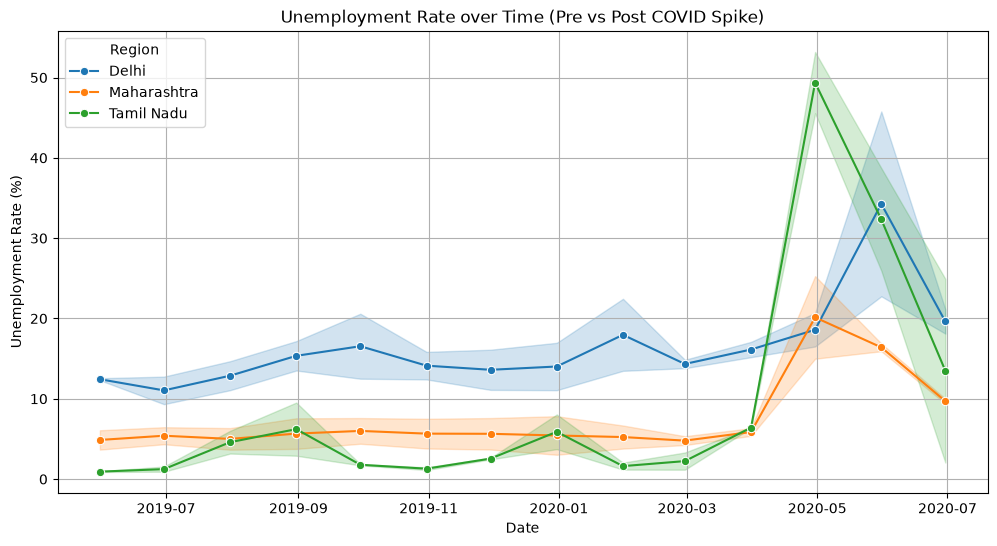

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
major_states = ['Maharashtra','Delhi','Tamil Nadu']
df_major = df[df['Region'].isin(major_states)]
sns.lineplot(data=df_major,x='Date',y='Estimated Unemployment Rate (%)',hue = 'Region',marker='o')
plt.title('Unemployment Rate over Time (Pre vs Post COVID Spike)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.show()

#Observation: State-Wise Time Series
Tamil Nadu and Delhi both show dramatic unemployment spikes(nearing 50%) in April-May 2020,While Maharashtra's rise was more moderate - suggesting some regional econmies were hit far harder by th lockdown than others.

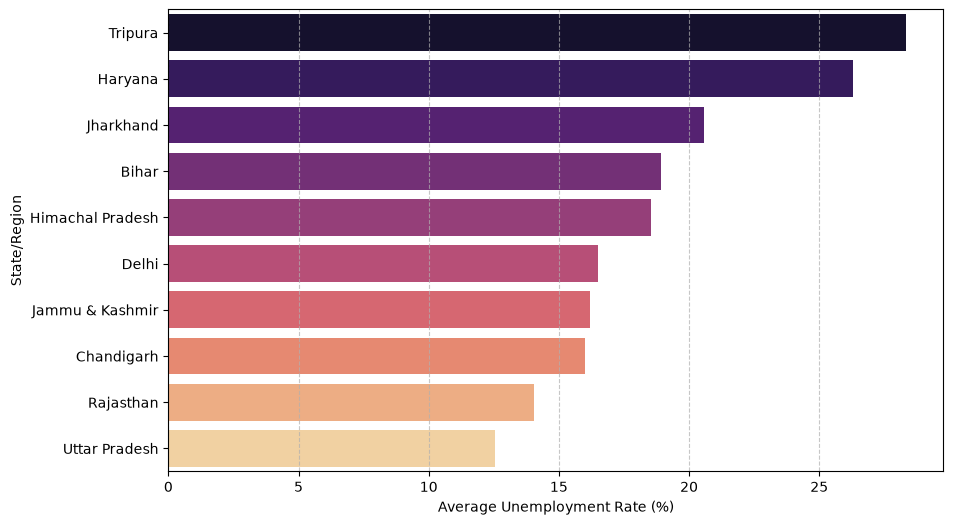

In [12]:
plt.figure(figsize=(10,6))
top_10 = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending = False).head(10)
sns.barplot(x=top_10.values,y=top_10.index,hue = top_10.index,palette='magma',legend = False)
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State/Region')
plt.grid(axis='x',linestyle='--',alpha=0.7)
plt.show()

#Observation: Top 10 States
Tripura,Haryana,and Jarkhand have  the highest average unemployment rates(above 20%),all exceding 15% even at the 10th-ranked state (uttar Pradesh)-showing that unemployment challenges are concentrated in specific northen and hill states.

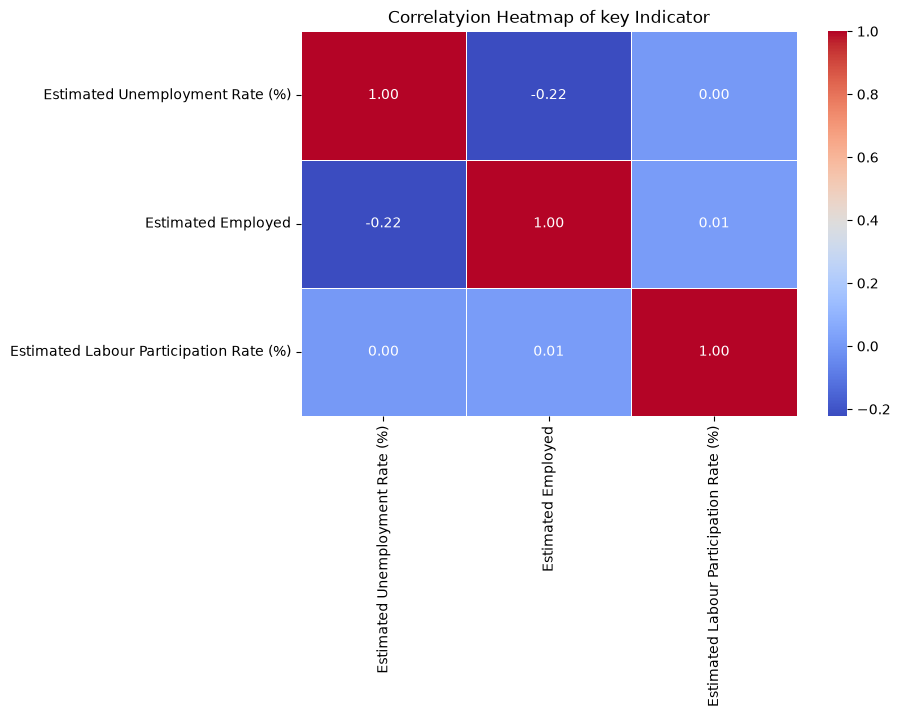

In [16]:
plt.figure(figsize=(8,5))
numeric_cols = ['Estimated Unemployment Rate (%)','Estimated Employed','Estimated Labour Participation Rate (%)']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot = True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlatyion Heatmap of key Indicator')
plt.show()

#Observation: Correlation Analysis
Unemployment rate rate shows a weak negative correlation (-0.22) with employment numbers, and near-zero correlation with labour participation rate - suggesting unemployment isn't simply driven by fewer people seeking work.